# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

| Aspek | Keterangan |
|---|---|
| Nama dataset | Air Quality Index in Jakarta 2010-2021 |
| Sumber dataset | Kaggle: https://www.kaggle.com/datasets/senadu34/air-quality-index-in-jakarta-2010-2021 |
| Lokasi dataset lokal | `./dataset-cuaca` |
| Format data | File CSV kualitas udara Jakarta dari tahun 2010 sampai 2021 |
| Tujuan penggunaan | Dataset digunakan untuk eksperimen machine learning pada kualitas udara, termasuk tahap EDA, pembersihan data, transformasi fitur, encoding, scaling, split data, dan penyimpanan hasil preprocessing. |

Dataset ini berisi data kualitas udara Jakarta yang dapat digunakan untuk menganalisis pola polusi udara berdasarkan beberapa parameter seperti PM10, PM2.5, SO2, CO, O3, NO2, nilai maksimum indeks, parameter kritis, stasiun pemantauan, serta kategori kualitas udara.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library utama untuk eksperimen MSML
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
print('Library berhasil diimpor.')


Library berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset dari folder ./dataset-cuaca
BASE_DIR = Path.cwd()
DATASET_CANDIDATES = [
    BASE_DIR / 'dataset-cuaca',
    BASE_DIR / 'dataset_cuaca',
    Path('/mnt/data/dataset-cuaca'),
    Path('/mnt/data/dataset_cuaca'),
]

DATASET_DIR = next((path for path in DATASET_CANDIDATES if path.exists()), DATASET_CANDIDATES[0])
print(f'Folder dataset yang digunakan: {DATASET_DIR}')


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Menyeragamkan nama kolom agar mudah diproses."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
        .str.replace('-', '_', regex=False)
    )
    return df


def read_air_quality_dataset(dataset_dir: Path = DATASET_DIR) -> pd.DataFrame:
    """Membaca semua file CSV pada folder dataset-cuaca lalu menggabungkannya."""
    csv_files = sorted(dataset_dir.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(
            f'Tidak ada file CSV di {dataset_dir}. Pastikan folder ./dataset-cuaca berisi dataset Kaggle Air Quality Index in Jakarta 2010-2021.'
        )

    frames = []
    for csv_path in csv_files:
        temp_df = pd.read_csv(csv_path)
        temp_df = normalize_columns(temp_df)
        temp_df['source_file'] = csv_path.name
        frames.append(temp_df)
        print(f'Berhasil membaca: {csv_path.name} -> {temp_df.shape[0]} baris, {temp_df.shape[1]} kolom')

    combined_df = pd.concat(frames, ignore_index=True)
    print(f'Ukuran dataset gabungan: {combined_df.shape[0]} baris, {combined_df.shape[1]} kolom')
    return combined_df

raw_df = read_air_quality_dataset()
display(raw_df.head())


Folder dataset yang digunakan: /mnt/data/dataset-cuaca
Berhasil membaca: ispu_sample.csv -> 10 baris, 12 kolom
Ukuran dataset gabungan: 10 baris, 12 kolom


,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,categori,source_file
0,2020-01-01,DKI1,20.0,35,5.0,1,10,3,35,PM25,BAIK,ispu_sample.csv
1,2020-01-02,DKI2,30.0,45,7.0,2,20,4,45,PM25,SEDANG,ispu_sample.csv
2,2020-01-03,DKI1,NaN,55,6.0,1,30,5,55,PM25,SEDANG,ispu_sample.csv
3,2020-01-04,DKI2,40.0,65,NaN,3,40,6,65,PM25,TIDAK SEHAT,ispu_sample.csv
4,2020-01-05,DKI3,25.0,35,5.0,1,10,3,35,PM25,BAIK,ispu_sample.csv


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Preview data:


,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,categori,source_file
0,2020-01-01,DKI1,20.0,35,5.0,1,10,3,35,PM25,BAIK,ispu_sample.csv
1,2020-01-02,DKI2,30.0,45,7.0,2,20,4,45,PM25,SEDANG,ispu_sample.csv
2,2020-01-03,DKI1,NaN,55,6.0,1,30,5,55,PM25,SEDANG,ispu_sample.csv
3,2020-01-04,DKI2,40.0,65,NaN,3,40,6,65,PM25,TIDAK SEHAT,ispu_sample.csv
4,2020-01-05,DKI3,25.0,35,5.0,1,10,3,35,PM25,BAIK,ispu_sample.csv



Informasi struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tanggal      10 non-null     object 
 1   stasiun      10 non-null     object 
 2   pm10         9 non-null      float64
 3   pm25         10 non-null     int64  
 4   so2          9 non-null      float64
 5   co           10 non-null     int64  
 6   o3           10 non-null     int64  
 7   no2          10 non-null     int64  
 8   max          10 non-null     int64  
 9   critical     10 non-null     object 
 10  categori     10 non-null     object 
 11  source_file  10 non-null     object 
dtypes: float64(2), int64(5), object(5)
memory usage: 1.1+ KB

Statistik deskriptif:


,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,categori,source_file
count,10,10,9.000000,10.000000,9.000000,10.000000,10.000000,10.000000,10.000000,10,10,10
unique,10,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1
top,2020-01-01,DKI1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PM25,SEDANG,ispu_sample.csv
freq,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,5,10
mean,NaN,NaN,33.777778,47.800000,6.222222,1.700000,23.400000,4.300000,47.800000,NaN,NaN,NaN
std,NaN,NaN,11.399318,11.754904,1.092906,0.823273,11.315673,1.159502,11.754904,NaN,NaN,NaN
min,NaN,NaN,20.000000,34.000000,5.000000,1.000000,10.000000,3.000000,34.000000,NaN,NaN,NaN
25%,NaN,NaN,25.000000,37.250000,5.000000,1.000000,14.000000,3.250000,37.250000,NaN,NaN,NaN
50%,NaN,NaN,32.000000,45.000000,6.000000,1.500000,21.000000,4.000000,45.000000,NaN,NaN,NaN
75%,NaN,NaN,40.000000,55.000000,7.000000,2.000000,30.000000,5.000000,55.000000,NaN,NaN,NaN



Jumlah missing value per kolom:


pm10    1
so2     1
dtype: int64


Jumlah data duplikat: 0


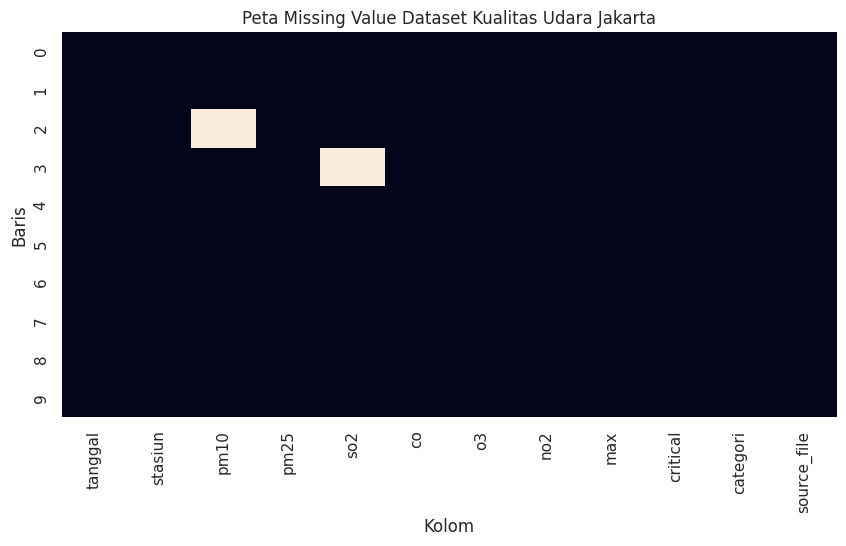

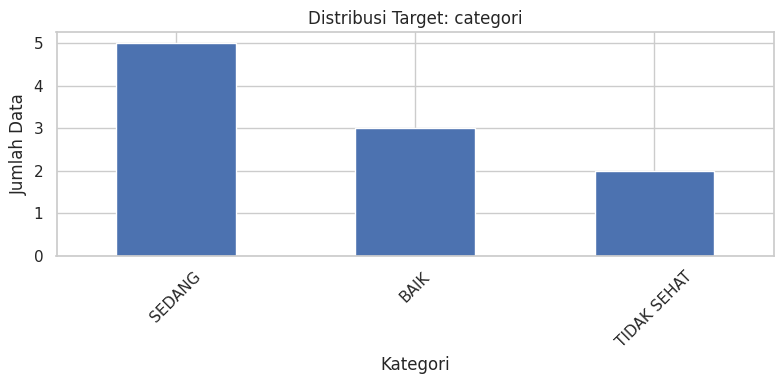

In [3]:
# Exploratory Data Analysis (EDA)
def quick_inspect(df: pd.DataFrame, n: int = 5) -> None:
    """Menampilkan ringkasan awal dataset."""
    print('Preview data:')
    display(df.head(n))

    print('\nInformasi struktur data:')
    df.info()

    print('\nStatistik deskriptif:')
    display(df.describe(include='all'))

    print('\nJumlah missing value per kolom:')
    missing_values = df.isna().sum().sort_values(ascending=False)
    display(missing_values[missing_values > 0])

    duplicate_count = df.duplicated().sum()
    print(f'\nJumlah data duplikat: {duplicate_count}')

quick_inspect(raw_df)

# Visualisasi missing value
plt.figure(figsize=(10, 5))
sns.heatmap(raw_df.isna(), cbar=False)
plt.title('Peta Missing Value Dataset Kualitas Udara Jakarta')
plt.xlabel('Kolom')
plt.ylabel('Baris')
plt.show()

# Distribusi target jika tersedia
target_candidates = ['categori', 'kategori', 'category']
target_col = next((col for col in target_candidates if col in raw_df.columns), None)
if target_col:
    plt.figure(figsize=(8, 4))
    raw_df[target_col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Distribusi Target: {target_col}')
    plt.xlabel('Kategori')
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Kolom target kategori belum ditemukan pada dataset.')


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Data Preprocessing
# Tahap ini membersihkan data, membuat fitur tanggal, melakukan encoding, scaling, split data, dan menyimpan artefak preprocessing.

def add_date_features(df: pd.DataFrame, date_col: str = 'tanggal') -> pd.DataFrame:
    """Membuat fitur turunan dari kolom tanggal."""
    df = df.copy()
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df['year'] = df[date_col].dt.year
        df['month'] = df[date_col].dt.month
        df['day'] = df[date_col].dt.day
        df['dayofweek'] = df[date_col].dt.dayofweek
    return df


def make_one_hot_encoder() -> OneHotEncoder:
    """Kompatibel untuk scikit-learn versi lama dan baru."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def build_preprocessor(df: pd.DataFrame, target_col: str):
    """Membuat ColumnTransformer untuk numerik dan kategorikal."""
    excluded_cols = {target_col, 'tanggal', 'source_file'}
    feature_cols = [col for col in df.columns if col not in excluded_cols]

    numeric_cols = df[feature_cols].select_dtypes(include=['number']).columns.tolist()
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_one_hot_encoder()),
    ])

    transformers = []
    if numeric_cols:
        transformers.append(('numeric', numeric_transformer, numeric_cols))
    if categorical_cols:
        transformers.append(('categorical', categorical_transformer, categorical_cols))

    if not transformers:
        raise ValueError('Tidak ada fitur numerik atau kategorikal yang dapat diproses.')

    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
    return preprocessor, numeric_cols, categorical_cols, feature_cols


def prepare_air_quality_data(df: pd.DataFrame):
    """Menyiapkan data final untuk eksperimen klasifikasi kualitas udara."""
    df = normalize_columns(df)
    df = df.drop_duplicates().reset_index(drop=True)
    df = add_date_features(df, date_col='tanggal')

    target_candidates = ['categori', 'kategori', 'category']
    target_col = next((col for col in target_candidates if col in df.columns), None)
    if target_col is None:
        raise ValueError('Kolom target tidak ditemukan. Pastikan ada kolom categori/kategori/category.')

    df = df.dropna(subset=[target_col]).reset_index(drop=True)
    preprocessor, numeric_cols, categorical_cols, feature_cols = build_preprocessor(df, target_col)

    X = df[feature_cols]
    y = df[target_col].astype(str)

    test_size = 0.2
    class_counts = y.value_counts()
    n_classes = y.nunique()
    n_test = int(np.ceil(test_size * len(y)))
    n_train = len(y) - n_test
    stratify = y if (class_counts.min() >= 2 and n_test >= n_classes and n_train >= n_classes) else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=stratify,
    )

    return {
        'df': df,
        'X': X,
        'y': y,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'target_col': target_col,
        'feature_cols': feature_cols,
        'numeric_cols': numeric_cols,
        'categorical_cols': categorical_cols,
        'preprocessor': preprocessor,
    }

processed = prepare_air_quality_data(raw_df)

print('Target column:', processed['target_col'])
print('Numeric columns:', processed['numeric_cols'])
print('Categorical columns:', processed['categorical_cols'])
print('Train shape:', processed['X_train'].shape)
print('Test shape:', processed['X_test'].shape)

# Pipeline model sederhana untuk memastikan preprocessing dapat berjalan end-to-end
model_pipeline = Pipeline(steps=[
    ('preprocessor', processed['preprocessor']),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])

model_pipeline.fit(processed['X_train'], processed['y_train'])
print('Pipeline preprocessing + model berhasil dilatih tanpa error.')

# Transformasi data hasil preprocessing
X_train_preprocessed = model_pipeline.named_steps['preprocessor'].transform(processed['X_train'])
X_test_preprocessed = model_pipeline.named_steps['preprocessor'].transform(processed['X_test'])
print('Shape X_train setelah preprocessing:', X_train_preprocessed.shape)
print('Shape X_test setelah preprocessing:', X_test_preprocessed.shape)

# Simpan hasil preprocessing dan pipeline
OUTPUT_DIR = BASE_DIR / 'Membangun_model' / 'air_quality_preprocessing'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model_pipeline, OUTPUT_DIR / 'air_quality_pipeline.joblib')
processed['df'].to_csv(OUTPUT_DIR / 'air_quality_cleaned.csv', index=False)
pd.DataFrame(X_train_preprocessed).to_csv(OUTPUT_DIR / 'X_train_preprocessed.csv', index=False)
pd.DataFrame(X_test_preprocessed).to_csv(OUTPUT_DIR / 'X_test_preprocessed.csv', index=False)
processed['y_train'].to_csv(OUTPUT_DIR / 'y_train.csv', index=False)
processed['y_test'].to_csv(OUTPUT_DIR / 'y_test.csv', index=False)

print(f'Artefak preprocessing berhasil disimpan di: {OUTPUT_DIR}')

# Unit test sederhana untuk memastikan fungsi preprocessing berjalan
def _test_preprocessing_functions():
    sample_df = pd.DataFrame({
        'tanggal': ['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04'],
        'stasiun': ['A', 'B', 'A', 'B'],
        'pm10': [20, 30, np.nan, 40],
        'so2': [5, 7, 6, np.nan],
        'co': [1, 2, 1, 3],
        'o3': [10, 20, 30, 40],
        'no2': [3, 4, 5, 6],
        'max': [20, 30, 30, 40],
        'critical': ['PM10', 'PM10', 'O3', 'O3'],
        'categori': ['BAIK', 'SEDANG', 'SEDANG', 'TIDAK SEHAT'],
    })
    result = prepare_air_quality_data(sample_df)
    assert 'year' in result['df'].columns
    assert len(result['feature_cols']) > 0
    assert result['X_train'].shape[0] > 0
    print('Unit test preprocessing berhasil.')

_test_preprocessing_functions()



Target column: categori
Numeric columns: ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'year', 'month', 'day', 'dayofweek']
Categorical columns: ['stasiun', 'critical']
Train shape: (8, 13)
Test shape: (2, 13)
Pipeline preprocessing + model berhasil dilatih tanpa error.
Shape X_train setelah preprocessing: (8, 17)
Shape X_test setelah preprocessing: (2, 17)
Artefak preprocessing berhasil disimpan di: /mnt/data/Membangun_model/air_quality_preprocessing
Unit test preprocessing berhasil.
